✅ Saved: ../trials/enhanced_results\trial_enhanced_rho0.3_k1.jpg


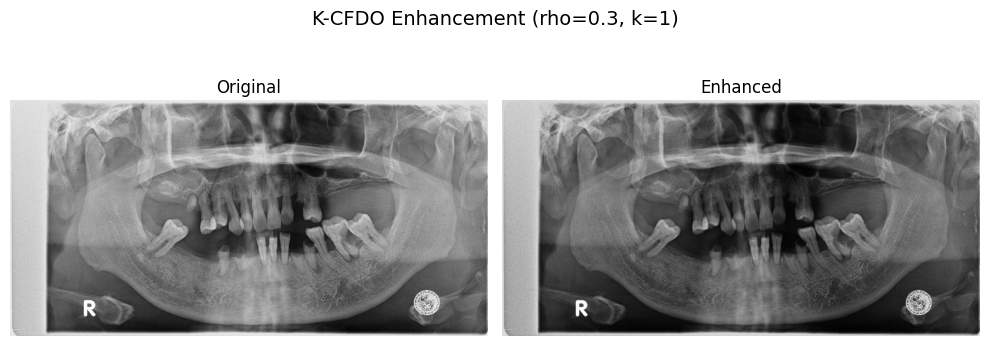

✅ Saved: ../trials/enhanced_results\trial_enhanced_rho0.3_k1.5.jpg


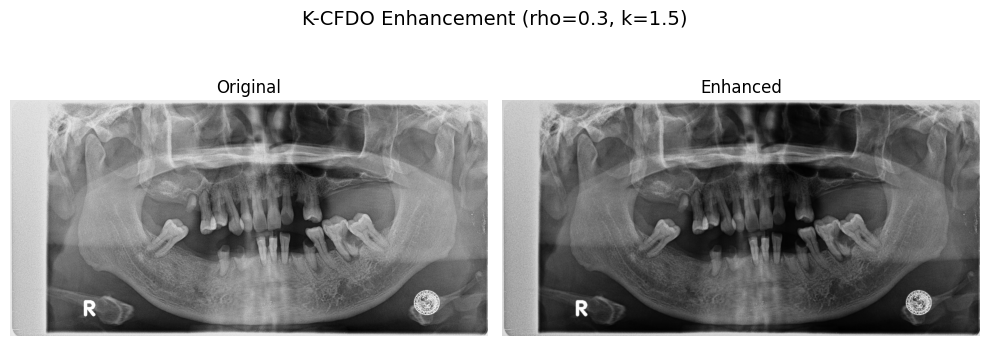

✅ Saved: ../trials/enhanced_results\trial_enhanced_rho0.3_k2.jpg


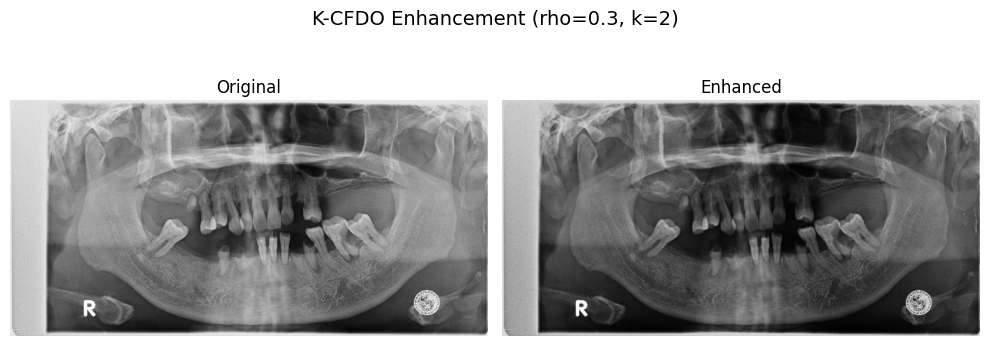

✅ Saved: ../trials/enhanced_results\trial_enhanced_rho0.5_k1.jpg


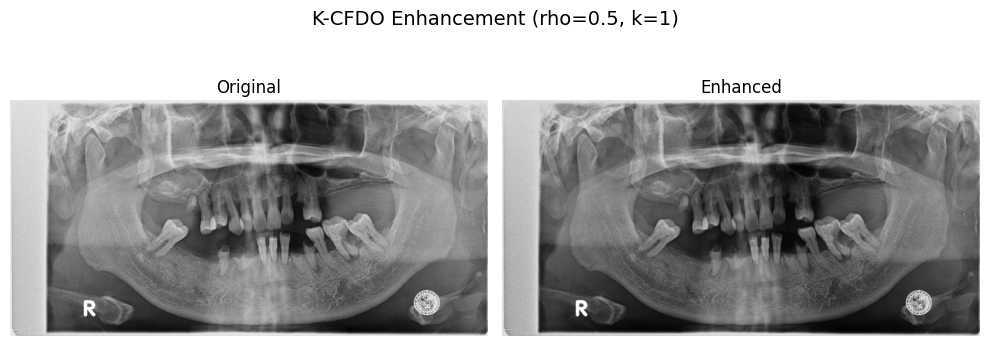

✅ Saved: ../trials/enhanced_results\trial_enhanced_rho0.5_k1.5.jpg


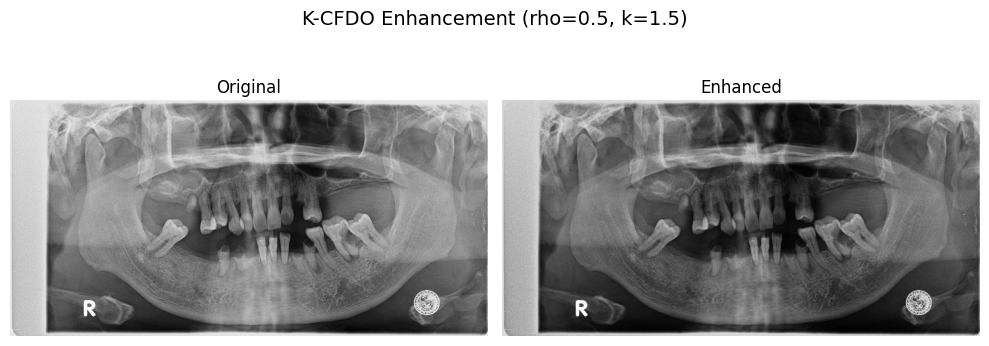

✅ Saved: ../trials/enhanced_results\trial_enhanced_rho0.5_k2.jpg


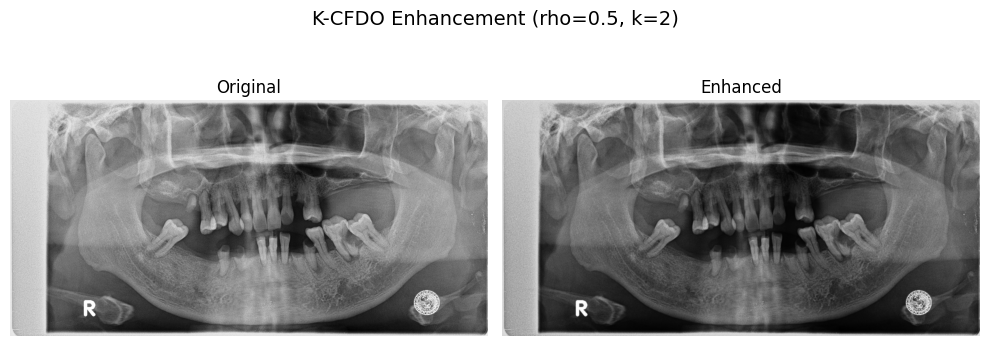

✅ Saved: ../trials/enhanced_results\trial_enhanced_rho0.7_k1.jpg


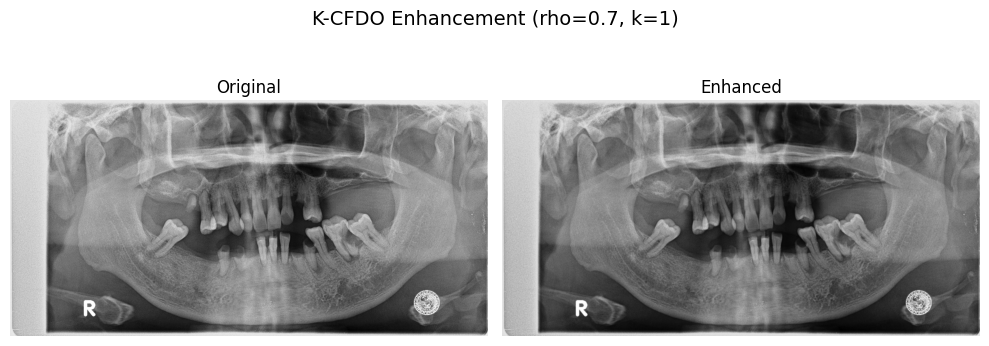

✅ Saved: ../trials/enhanced_results\trial_enhanced_rho0.7_k1.5.jpg


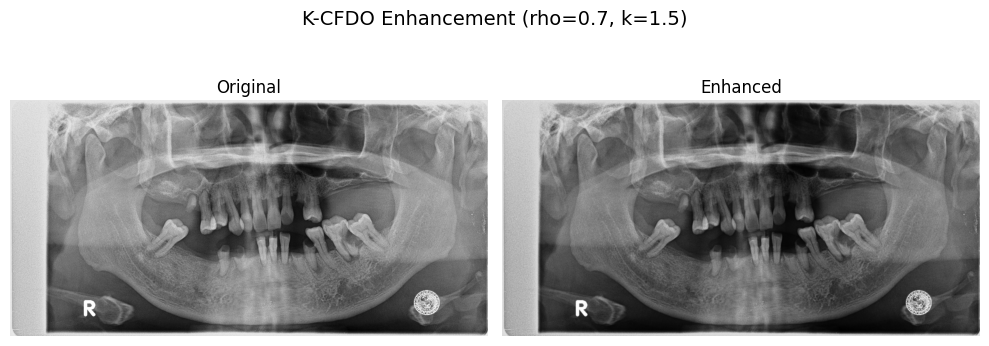

✅ Saved: ../trials/enhanced_results\trial_enhanced_rho0.7_k2.jpg


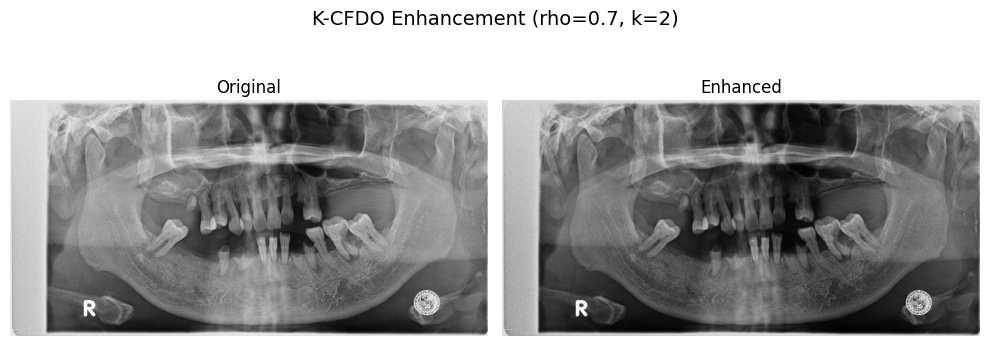

In [8]:
import os
import numpy as np
import cv2
from tqdm import tqdm
from scipy import special

def k_gamma_function(z, k=2):
    """
    Implements the k-Gamma function: Γ_k(z) = k^(z/k - 1) * Γ(z/k)
    
    Parameters:
    -----------
    z : float
        Input value
    k : float
        The k parameter
        
    Returns:
    --------
    float : k-Gamma function value
    """
    return k**(z/k - 1) * special.gamma(z/k)

def k_mittag_leffler(r, rho, k=2, max_terms=50):
    """
    Computes the k-Mittag-Leffler function as shown in equation (9)
    E^(1,1-ρ/k)_k(r)
    
    Parameters:
    -----------
    r : float
        Pixel probability value (0-1)
    rho : float
        Fractional order parameter
    k : float
        The k parameter
    max_terms : int
        Maximum number of terms in the summation
        
    Returns:
    --------
    float : k-Mittag-Leffler function value
    """
    # STEP 4: Using Eq. (9) to determine the proposed K-CFDO
    # Initialize the summation
    result = 0
    
    # Compute the series as per equation (9)
    for n in range(max_terms):
        # r^n / (n! * Γ_k(1+n-ρ/k))
        numerator = r**n
        denominator = np.math.factorial(n) * k_gamma_function(1 + n - rho/k, k)
        term = numerator / denominator
        result += term
        
        # Stop if terms become very small
        if abs(term) < 1e-10:
            break
    
    # Multiply by r^(1-ρ/k) as in equation (9)
    result *= r**(1 - rho/k)
    
    return result

def calculate_pixel_probability(image):
    """
    Calculate the probability value (r) for each pixel
    For simplicity, normalized pixel intensity is used as probability
    
    Parameters:
    -----------
    image : ndarray
        Input grayscale image
        
    Returns:
    --------
    ndarray : Probability map with same shape as input
    """
    # STEP 3: Determine the pixel's probability value (r)
    # Normalize to [0,1] range
    if image.max() > 1.0:
        normalized = image.astype(np.float64) / 255.0
    else:
        normalized = image.astype(np.float64)
    
    return normalized

def k_cfdo_enhancement_full(image, rho=0.5, k=2, window_size=3):
    """
    Complete implementation of K-CFDO enhancement following all algorithm steps
    
    Parameters:
    -----------
    image : ndarray
        Input grayscale image
    rho : float
        Fractional order parameter
    k : float
        The k parameter
    window_size : int
        Size of the window for neighborhood processing
        
    Returns:
    --------
    ndarray : Enhanced image
    """
    # STEP 1: Consider the source image (already done - input parameter)
    img = image.astype(np.float64)
    
    # STEP 2: Set the parameters of ρ and k (done via function parameters)
    
    # STEP 3: Determine the pixel's probability value (r)
    r_map = calculate_pixel_probability(img)
    
    # Create output image
    n, m = img.shape
    enhanced_img = np.zeros_like(img)
    
    # Pad the image for window processing
    pad_width = window_size // 2
    padded_img = np.pad(img / 255.0, pad_width, mode='reflect')
    padded_r = np.pad(r_map, pad_width, mode='reflect')
    
    # STEP 5: Calculate the enhanced image using Eq. (10)
    # Loop through each pixel in the original image
    for i in range(n):
        for j in range(m):
            # Initialize enhancement value
            enhancement = 0
            
            # Apply the double summation as shown in Eq. (10)
            for di in range(window_size):
                for dj in range(window_size):
                    # Get pixel position in padded image
                    pi = i + di
                    pj = j + dj
                    
                    # Get pixel value and probability
                    pixel_value = padded_img[pi, pj]
                    r_value = padded_r[pi, pj]
                    
                    # Calculate terms from Eq. (10)
                    r_term = r_value**(1 - rho/k)
                    gamma_term = k_gamma_function(2 - rho/k, k)
                    
                    # Add to the enhancement value
                    enhancement += pixel_value * r_term / gamma_term
            
            # Store the enhanced pixel value
            enhanced_img[i, j] = enhancement
    
    # Normalize the enhanced image
    if enhanced_img.min() != enhanced_img.max():
        enhanced_img = (enhanced_img - enhanced_img.min()) / (enhanced_img.max() - enhanced_img.min())
    
    return (enhanced_img * 255).astype(np.uint8)

# Main execution for a single image
if __name__ == "__main__":
    trial_path = "../trials/trial.jpg"
    image = cv2.imread(trial_path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        print(f"Could not read the image at {trial_path}")
    else:
        rho_values = [0.3, 0.5, 0.7]
        k_values = [1, 1.5, 2]

        output_dir = "../trials/enhanced_results"
        os.makedirs(output_dir, exist_ok=True)

        for rho in rho_values:
            for k in k_values:
                enhanced_img = k_cfdo_enhancement_full(image, rho=rho, k=k)

                out_filename = f"trial_enhanced_rho{rho}_k{k}.jpg"
                out_path = os.path.join(output_dir, out_filename)
                cv2.imwrite(out_path, enhanced_img)
                print(f"Saved: {out_path}")

                # Show side-by-side comparison
                plt.figure(figsize=(10, 4))
                plt.suptitle(f"K-CFDO Enhancement (rho={rho}, k={k})", fontsize=14)

                plt.subplot(1, 2, 1)
                plt.title("Original")
                plt.imshow(image, cmap='gray')
                plt.axis("off")

                plt.subplot(1, 2, 2)
                plt.title("Enhanced")
                plt.imshow(enhanced_img, cmap='gray')
                plt.axis("off")

                plt.tight_layout()
                plt.show()